In [1]:
import os 
import json
import pandas as pd
import glob

In [2]:
plog_paths = glob.glob('../plogs/*/*/*/*.json')

In [3]:
plogs = []
for i, plog_path in enumerate(plog_paths):
    _, plog_info = plog_path.split('/')[-2:]
    model_nm, h, w, trares, testres, clevel, mlevel = plog_info.split('.')[0].split('-')
    if mlevel[2:] == 'x':
        mlevel = 'null'
    elif mlevel[2:] == '0':
        mlevel = 'diag'

    clevel = int(clevel[2:])
    trares = int(trares)
    testres = int(testres)
    
    with open(plog_path, 'r') as f:
        plog = json.load(f)

    plog['model'] = model_nm
    plog['coarse_level'] = clevel
    plog['resolution'] = trares 
    plog['residual'] = mlevel

    plogs.append(plog) 

In [4]:
plog_df = pd.DataFrame(plogs)

In [9]:
plog_df.columns

Index(['bsz', 'tra_time', 'infer_time', 'tra_mem', 'infer_mem', 'model_FLOPs',
       'model_nparam', 'model', 'coarse_level', 'resolution', 'residual'],
      dtype='object')

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns 

#### Train Time on different residual type

In [6]:
plog_df.resolution.unique()

array([1024, 2048,  512, 4096])

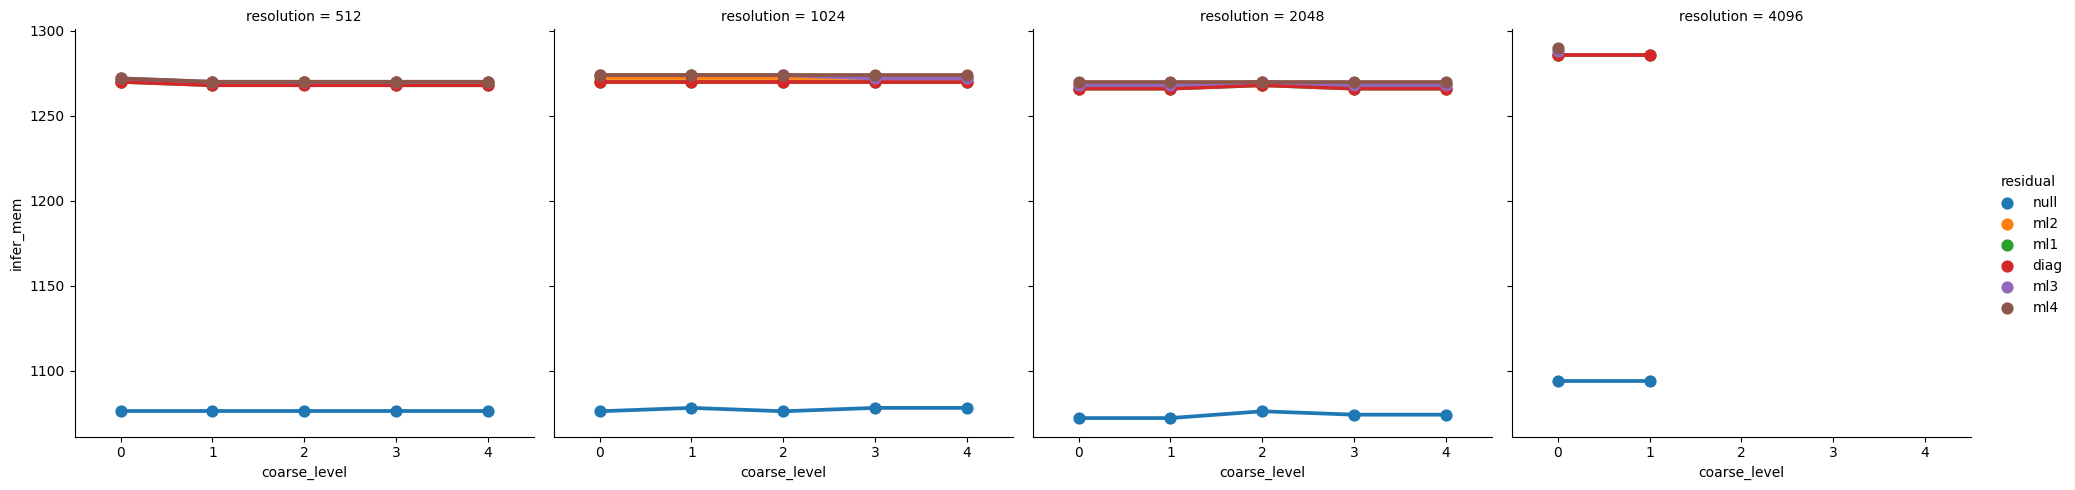

In [13]:
sub_df = plog_df[plog_df.model == 'fno1d']
g = sns.catplot(data=sub_df, x='coarse_level', y='infer_mem', hue='residual', col='resolution', kind='point')
# g.set(yscale='log')